In [61]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [62]:
VECTOR_FILE = r"E:\Dyploma\Carolingus\Carolingus\runs\syntax_embedding\2025-01-19 17_49_56\repeat-1\embeddings\train-embeddings.json"

In [63]:
embeddings = json.load(open(VECTOR_FILE))
embeddings

{'AUR_888_II_18-101 (text)\\156-suae.png': [0.41907450556755066,
  -0.3071958124637604,
  -0.1986878365278244,
  -1.35495126247406,
  0.8066135048866272,
  -1.8717786073684692,
  0.5691788196563721,
  -0.7250239253044128,
  0.8149527311325073,
  -0.3026771545410156,
  -1.4329302310943604,
  -2.0408775806427,
  -1.4661357402801514,
  0.48200345039367676,
  0.008763604797422886,
  1.1554993391036987,
  0.9084737300872803,
  -0.835175633430481,
  -0.5055640935897827,
  -1.861011266708374,
  0.501534104347229,
  -0.10021346807479858,
  -2.0814332962036133,
  -0.28407514095306396,
  -1.2570698261260986,
  2.522146224975586,
  -0.34712985157966614,
  -0.7057651877403259,
  1.3732327222824097,
  -0.4478819668292999,
  -0.8775303959846497,
  -0.20516961812973022,
  -1.4537956714630127,
  -0.5736455917358398,
  -0.2775071859359741,
  0.31183111667633057,
  3.8910672664642334,
  0.37472912669181824,
  0.14619269967079163,
  0.35188987851142883,
  -1.568015694618225,
  -0.6099434494972229,
  0.63

In [64]:
new_embedings = {}
for key in embeddings.keys():
    base_name = os.path.basename(key).split(".")[0]
    new_embedings[base_name] = embeddings[key]
embeddings = new_embedings

In [65]:
embeddings

{'156-suae': [0.41907450556755066,
  -0.3071958124637604,
  -0.1986878365278244,
  -1.35495126247406,
  0.8066135048866272,
  -1.8717786073684692,
  0.5691788196563721,
  -0.7250239253044128,
  0.8149527311325073,
  -0.3026771545410156,
  -1.4329302310943604,
  -2.0408775806427,
  -1.4661357402801514,
  0.48200345039367676,
  0.008763604797422886,
  1.1554993391036987,
  0.9084737300872803,
  -0.835175633430481,
  -0.5055640935897827,
  -1.861011266708374,
  0.501534104347229,
  -0.10021346807479858,
  -2.0814332962036133,
  -0.28407514095306396,
  -1.2570698261260986,
  2.522146224975586,
  -0.34712985157966614,
  -0.7057651877403259,
  1.3732327222824097,
  -0.4478819668292999,
  -0.8775303959846497,
  -0.20516961812973022,
  -1.4537956714630127,
  -0.5736455917358398,
  -0.2775071859359741,
  0.31183111667633057,
  3.8910672664642334,
  0.37472912669181824,
  0.14619269967079163,
  0.35188987851142883,
  -1.568015694618225,
  -0.6099434494972229,
  0.6306464672088623,
  -2.382580041

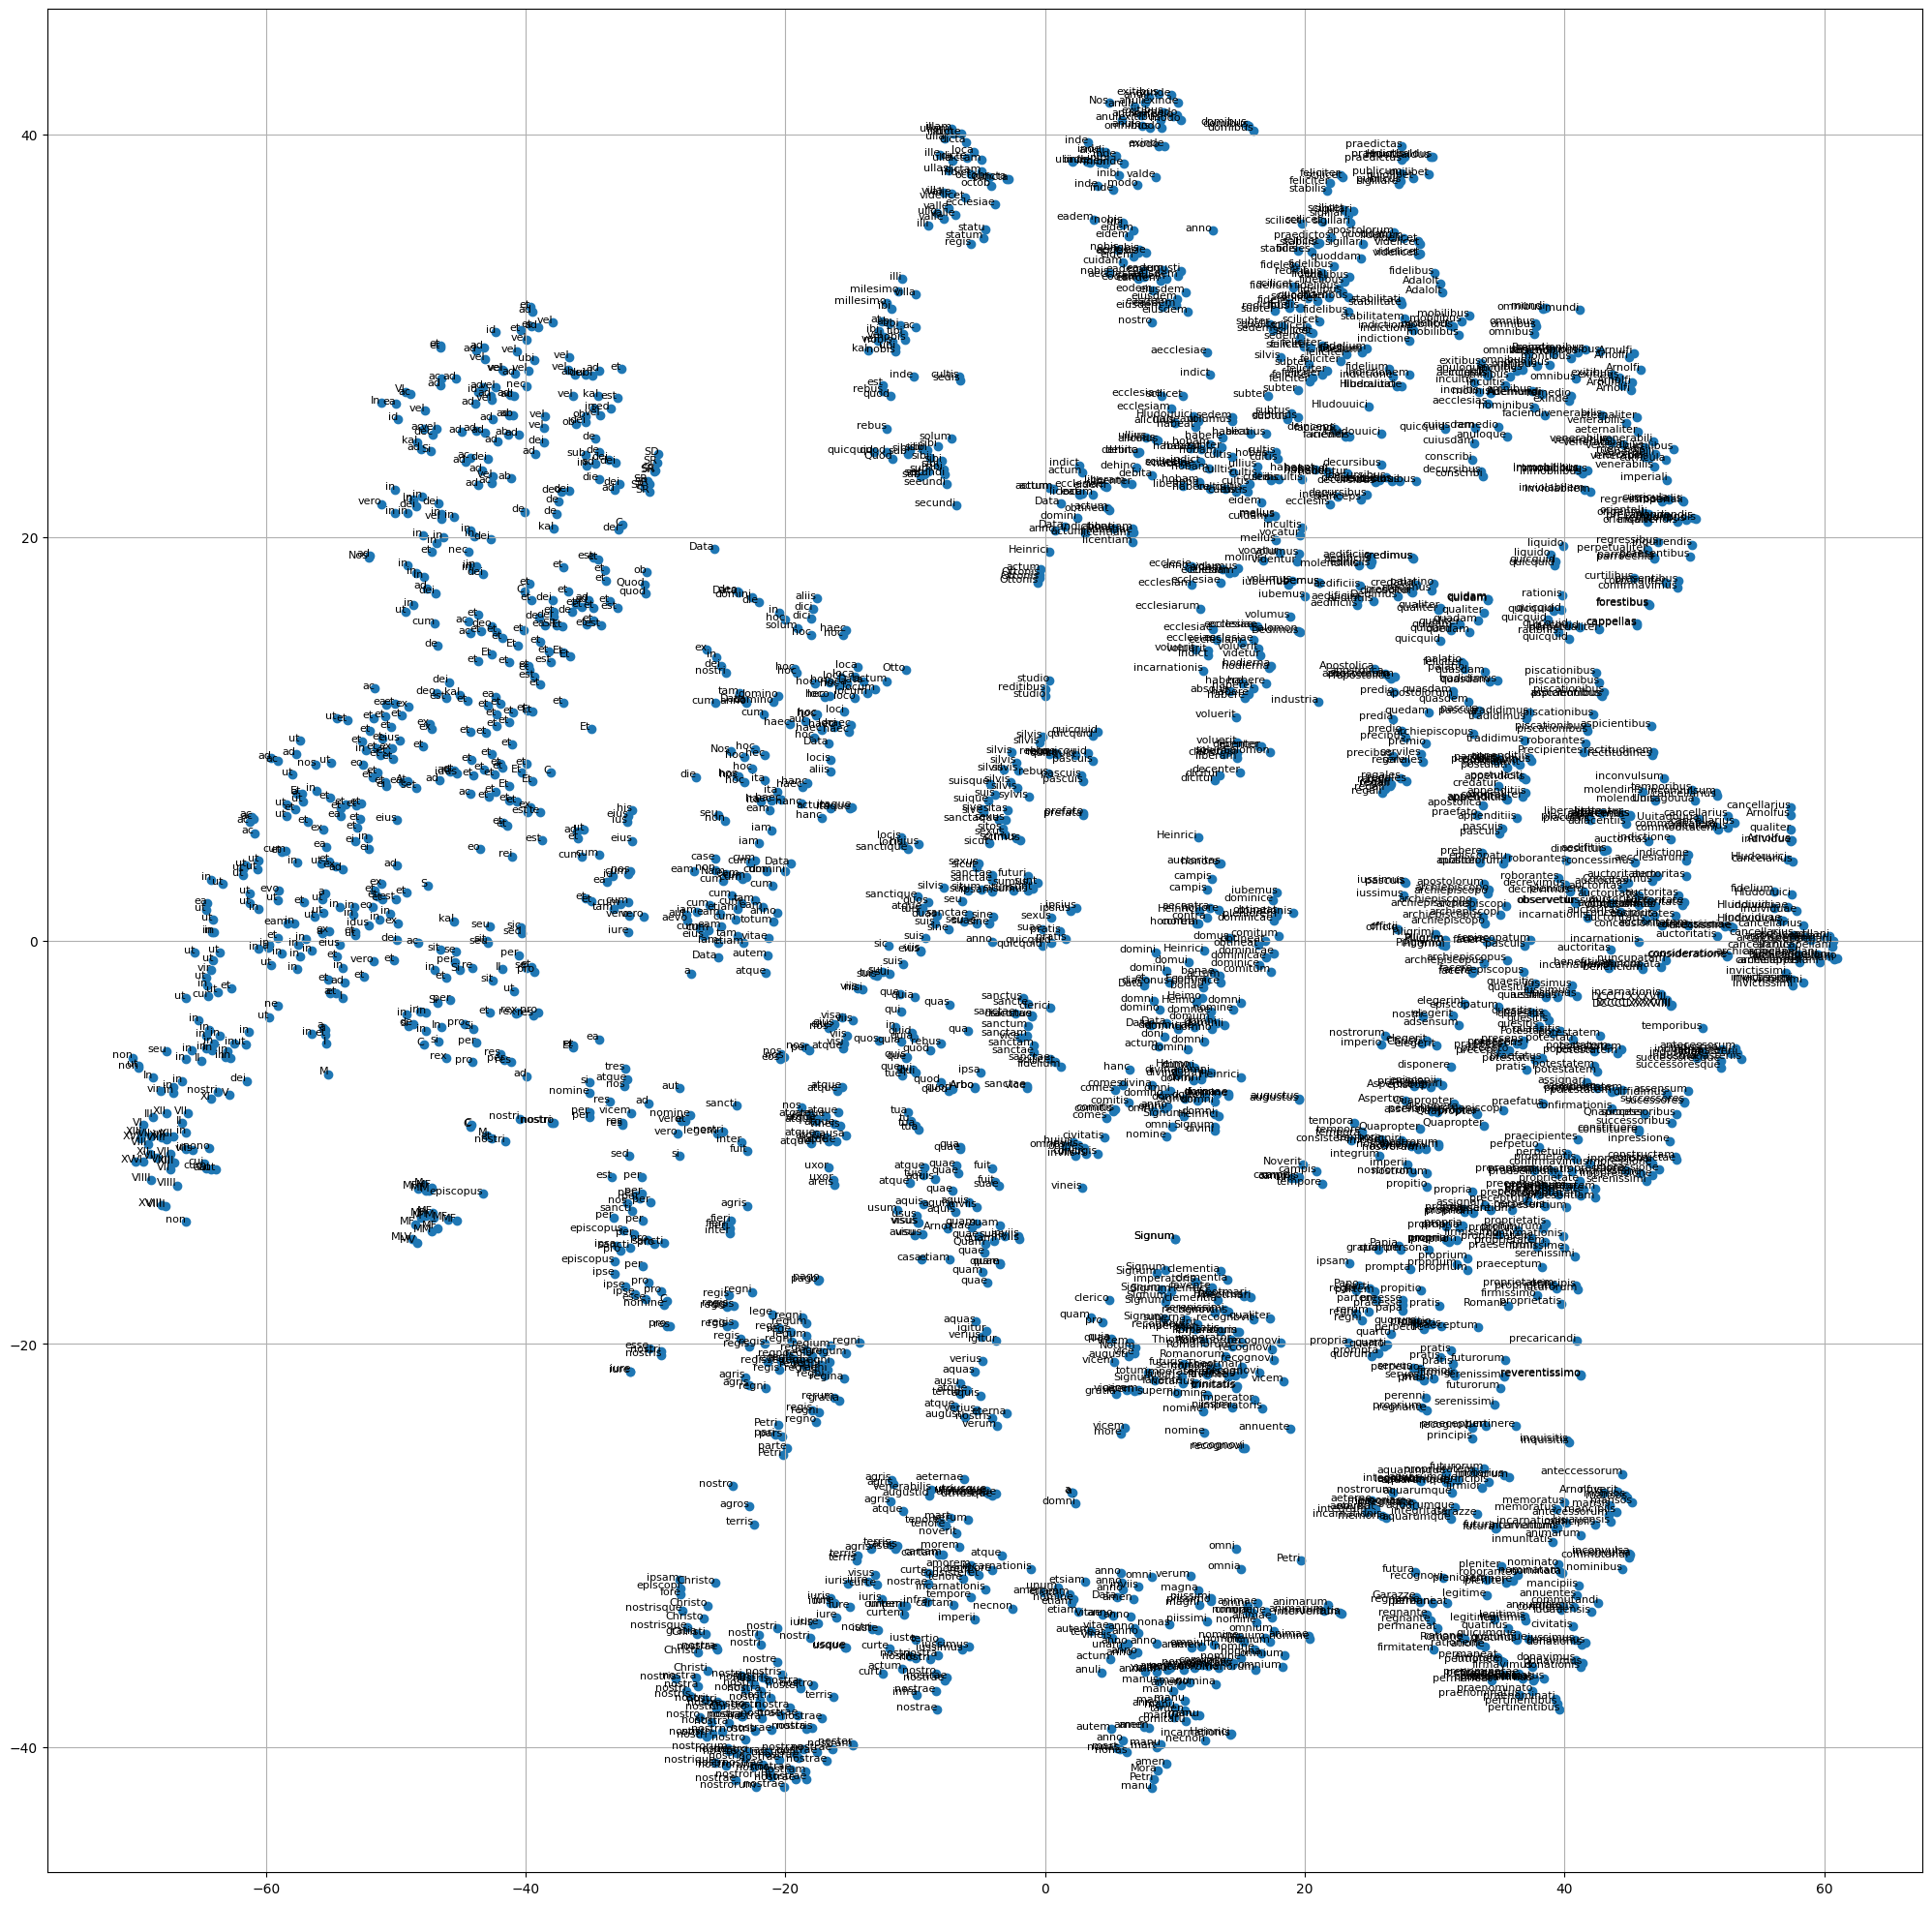

In [76]:
words, vectors = zip(*embeddings.items())
vectors = np.array(vectors)

tsne = TSNE(n_components=2)
reduced_vectors = tsne.fit_transform(vectors)

plt.figure(figsize=(25, 25))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], marker="o")
for word, (x, y) in zip(words, reduced_vectors):
    plt.text(x, y, word.split("-")[1], fontsize=8, ha="right")
plt.grid()
plt.show()

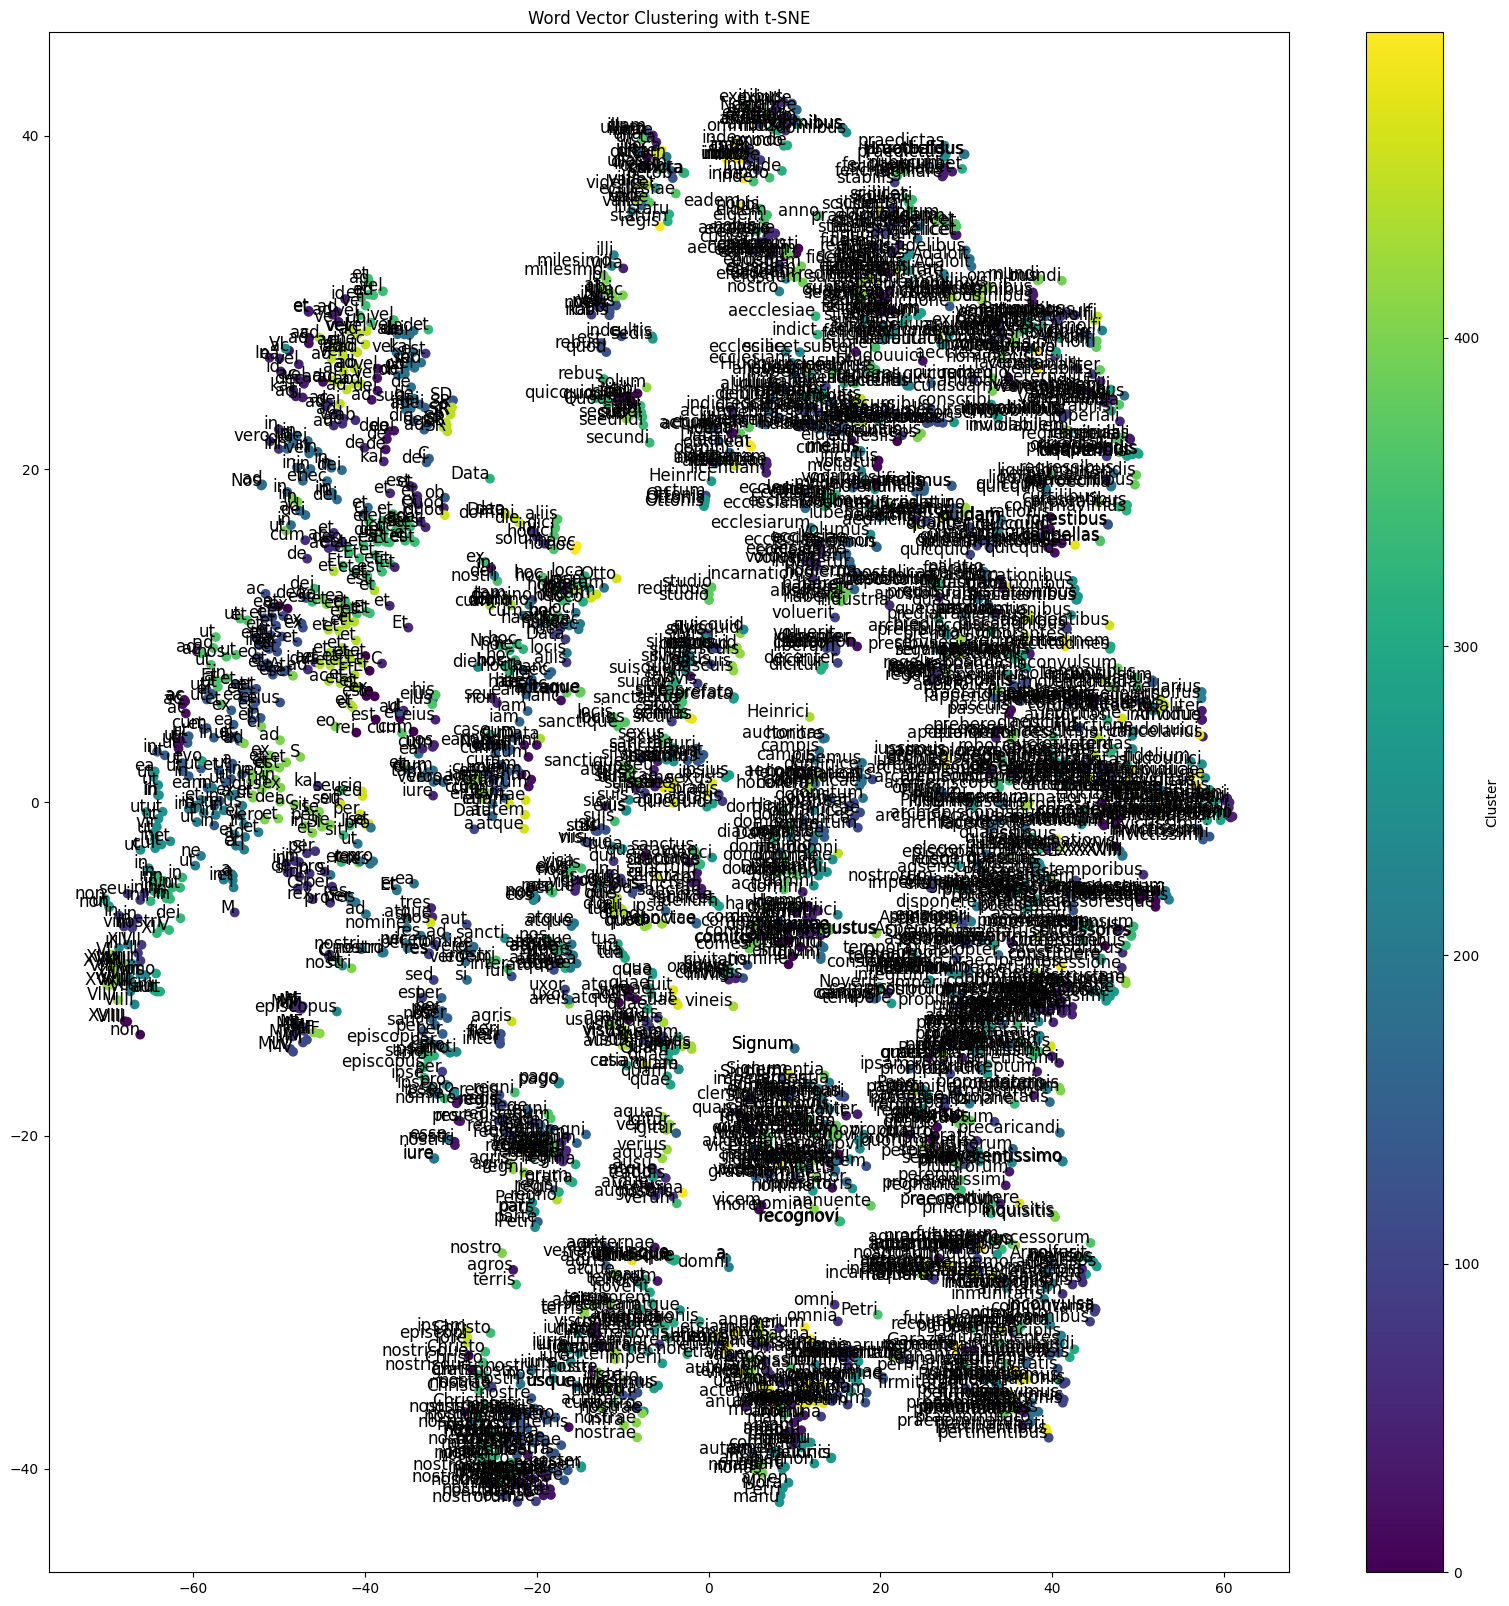

In [73]:
kmeans = KMeans(n_clusters=500, random_state=42, n_init="auto")
labels = kmeans.fit_predict(vectors)
plt.figure(figsize=(20, 20))
scatter = plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c=labels, cmap="viridis", marker='o')
plt.colorbar(scatter, label="Cluster")
plt.title("Word Vector Clustering with t-SNE")
for word, (x, y) in zip(words, reduced_vectors):
    plt.text(x, y, word.split("-")[1], fontsize=12, ha='right')
plt.show()